
**Actividad 1: Regresión Lineal**

**Objetivo:** Predecir la calificación final de los estudiantes (G3) a partir de notas previas y variables de desempeño escolar.

**Importación de Librerías**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Obtención de Datos**

In [2]:
# Cargamos el dataset desde la URL oficial
dat_csv = pd.read_csv('https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/04_Apply/Students_Alcohol_Consumption/student-mat.csv')

# Definimos x (Nota G2) e y (Nota Final G3)
datos_x = dat_csv.G2
datos_y = dat_csv.G3

x = []
y = []

for i in dat_csv.G2:
    x.append(i)

for j in dat_csv.G3:
    y.append(j)

print("Primeros 10 valores de x:", x[:10])
print("Primeros 10 valores de y:", y[:10])

X = np.array(x)
Y = np.array(y)

Primeros 10 valores de x: [6, 5, 8, 14, 10, 15, 12, 5, 18, 15]
Primeros 10 valores de y: [6, 6, 10, 15, 10, 15, 11, 6, 19, 15]


**Creación de los conjuntos de datos (80% entrenamiento y 20% prueba)**

In [3]:
# Calculo el 80 % de entrenamiento y 20 % prueba
datos_entrenamiento = int(0.8 * len(X))
datos_prueba = len(X) - datos_entrenamiento
print("Cantidad entrenamiento:", datos_entrenamiento)
print("Cantidad prueba:", datos_prueba)

# Datos de entrenamiento
X_entrenamiento = X[:datos_entrenamiento].reshape((datos_entrenamiento, 1))
Y_entrenamiento = Y[:datos_entrenamiento].reshape((datos_entrenamiento, 1))

# Datos de prueba
X_prueba = X[datos_entrenamiento:].reshape((datos_prueba, 1))
Y_prueba = Y[datos_entrenamiento:].reshape((datos_prueba, 1))

Cantidad entrenamiento: 316
Cantidad prueba: 79


**Modelado y ajuste sobre los datos de entrenamiento**

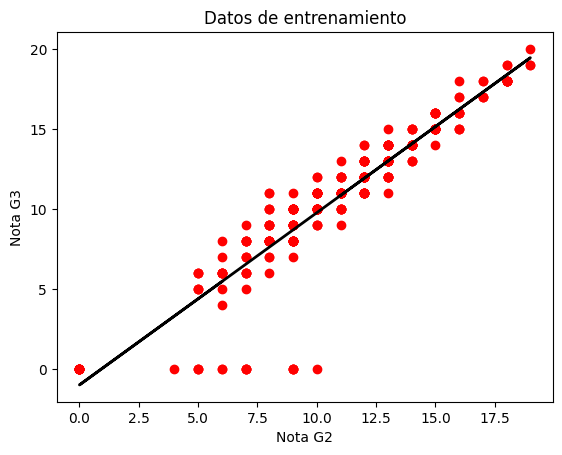

In [4]:
from sklearn import linear_model

# Creamos un objeto de regresión lineal
linear_regressor = linear_model.LinearRegression()

# Ajustamos la regresión a los datos de entrenamiento
linear_regressor.fit(X_entrenamiento, Y_entrenamiento)

# Y a partir de datos de regresión encontrados
Y_predicha_de_entrenamiento = linear_regressor.predict(X_entrenamiento)

plt.figure()
plt.scatter(X_entrenamiento, Y_entrenamiento, color='red')
plt.plot(X_entrenamiento, Y_predicha_de_entrenamiento, color='black', linewidth=2)
plt.title('Datos de entrenamiento')
plt.xlabel('Nota G2')
plt.ylabel('Nota G3')
plt.show()

**Evaluación y gráfico sobre los datos de prueba**

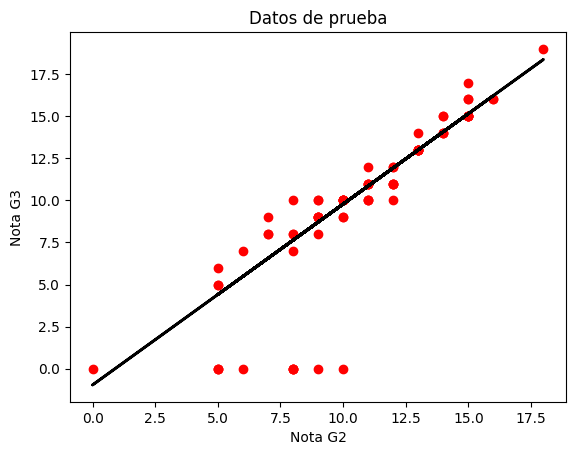

In [5]:
Y_predicha_de_prueba = linear_regressor.predict(X_prueba)

plt.figure()
plt.scatter(X_prueba, Y_prueba, color='red')
plt.plot(X_prueba, Y_predicha_de_prueba, color='black', linewidth=2)
plt.title('Datos de prueba')
plt.xlabel('Nota G2')
plt.ylabel('Nota G3')
plt.show()

**Cálculo de las métricas**

In [6]:
import sklearn.metrics as sm

print("Error absoluto medio =", round(sm.mean_absolute_error(Y_prueba, Y_predicha_de_prueba), 2))
print("Error cuadratico medio =", round(sm.mean_squared_error(Y_prueba, Y_predicha_de_prueba), 2))
print("Error absoluto mediano =", round(sm.median_absolute_error(Y_prueba, Y_predicha_de_prueba), 2))
print("Puntuación de varianza explicada =", round(sm.explained_variance_score(Y_prueba, Y_predicha_de_prueba), 2))
print("Puntuación R2 =", round(sm.r2_score(Y_prueba, Y_predicha_de_prueba), 2))

Error absoluto medio = 1.37
Error cuadratico medio = 6.84
Error absoluto mediano = 0.59
Puntuación de varianza explicada = 0.72
Puntuación R2 = 0.7
